# Sprint 3 - Preprocessing Pipeline Design

**Project:** AutoGuard AI - Insurance Underwriting Assistant  
**Scope:** preprocessing design and model-ready dataset preparation only  
**Dataset:** `data/raw/train.csv`, `data/raw/test.csv`  
**Target:** `is_claim`

This notebook applies the approved Sprint 2 feature decisions, designs the preprocessing contract, exports a reproducible modeling dataset, and stops before any model training or predictive evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from ml_pipeline import data_analyst as da
from ml_pipeline import data_encoder as enc

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [2]:
train_df = da.load_train_data()
test_df = da.load_test_data()
candidate_df = enc.sprint3_candidate_frame(train_df)
datasets = enc.build_model_ready_datasets(train_df, test_df)
pipeline = datasets['pipeline']

print('Raw train shape:', train_df.shape)
print('Raw test shape:', test_df.shape)
print('Sprint 3 candidate shape:', candidate_df.shape)
print('Final model-ready train shape:', datasets['X_train'].shape)
print('Final model-ready validation shape:', datasets['X_validation'].shape)
print('Final model-ready holdout shape:', datasets['X_holdout'].shape)

Raw train shape: (58592, 44)
Raw test shape: (39063, 43)
Sprint 3 candidate shape: (58592, 47)
Final model-ready train shape: (41015, 61)
Final model-ready validation shape: (8789, 61)
Final model-ready holdout shape: (8788, 61)


## Phase 1 - Feature Selection

In [3]:
drop_reasons = {
    'policy_id': 'Identifier only; remove leakage risk.',
    'max_torque': 'Superseded by parsed numeric features torque_nm and torque_rpm.',
    'max_power': 'Superseded by parsed numeric features power_bhp and power_rpm.',
    'is_rear_window_washer': 'Exact duplicate of is_rear_window_wiper in the approved Sprint 2 audit.',
    'is_central_locking': 'Exact duplicate of is_power_door_locks in the approved Sprint 2 audit.',
    'is_ecw': 'Exact duplicate of is_power_door_locks in the approved Sprint 2 audit.',
}

def sprint3_role(column: str) -> str:
    if column in enc.DERIVED_FEATURE_COLUMNS:
        return 'Derived numerical'
    if column in da.NUMERICAL_FEATURES:
        return 'Numerical'
    if column in da.YES_NO_FEATURES:
        return 'Binary'
    if column in enc.SPRINT3_FREQUENCY_COLUMNS:
        return 'Categorical (frequency-encoded)'
    if column in enc.SPRINT3_ONE_HOT_COLUMNS:
        return 'Categorical (one-hot)'
    return 'Other'

drop_table = pd.DataFrame(
    [{'feature': feature, 'action': 'Remove', 'justification': drop_reasons[feature]} for feature in enc.SPRINT3_DROP_FEATURES]
)
candidate_inventory = pd.DataFrame(
    [{'feature': feature, 'role': sprint3_role(feature)} for feature in enc.sprint3_feature_columns(train_df)]
)

print('Final candidate feature count before encoding:', len(candidate_inventory))
display(drop_table)
display(candidate_inventory)

Final candidate feature count before encoding: 46


,feature,action,justification
0,policy_id,Remove,Identifier only; remove leakage risk.
1,max_torque,Remove,Superseded by parsed numeric features torque_n...
2,max_power,Remove,Superseded by parsed numeric features power_bh...
3,is_rear_window_washer,Remove,Exact duplicate of is_rear_window_wiper in the...
4,is_central_locking,Remove,Exact duplicate of is_power_door_locks in the ...
5,is_ecw,Remove,Exact duplicate of is_power_door_locks in the ...


,feature,role
0,policy_tenure,Numerical
1,age_of_car,Numerical
2,age_of_policyholder,Numerical
3,area_cluster,Categorical (frequency-encoded)
4,population_density,Numerical
5,make,Categorical (one-hot)
6,segment,Categorical (one-hot)
7,model,Categorical (frequency-encoded)
8,fuel_type,Categorical (one-hot)
9,engine_type,Categorical (frequency-encoded)


## Phase 2 - Encoding Strategy

In [4]:
encoding_decisions = enc.sprint3_encoding_decision_table()
cardinality = pd.DataFrame(
    [
        {
            'feature': column,
            'unique_values': int(candidate_df[column].nunique(dropna=False)),
            'top_share_pct': float(candidate_df[column].value_counts(normalize=True, dropna=False).iloc[0] * 100),
        }
        for column in ['area_cluster', 'make', 'segment', 'model', 'fuel_type', 'engine_type', 'rear_brakes_type', 'transmission_type', 'steering_type']
    ]
)
encoding_review = encoding_decisions.merge(cardinality, on='feature', how='left')

estimated_output_width = (
    len(enc._unscaled_numeric_feature_columns())
    + len(enc._binary_feature_columns_after_selection())
    + len(enc.SPRINT3_FREQUENCY_COLUMNS)
    + sum(len(levels) for levels in pipeline['one_hot_levels'].values())
)

display(encoding_review)
print('Estimated final feature width after encoding:', estimated_output_width)

,feature,recommended_encoding,rationale,unique_values,top_share_pct
0,area_cluster,Frequency Encoding,High-cardinality nominal location cluster; fre...,22,23.303523
1,make,One-Hot Encoding,Low-cardinality nominal code; one-hot encoding...,5,65.070317
2,segment,One-Hot Encoding,Low-cardinality nominal segment label; one-hot...,6,31.256827
3,model,Frequency Encoding,Moderate-cardinality nominal vehicle model; fr...,11,25.512015
4,fuel_type,One-Hot Encoding,Very low-cardinality nominal variable; one-hot...,3,35.042327
5,engine_type,Frequency Encoding,Moderate-cardinality nominal engine family; fr...,11,25.512015
6,rear_brakes_type,One-Hot Encoding,Two-level nominal category; one-hot encoding i...,2,76.075232
7,transmission_type,One-Hot Encoding,Two-level nominal category; one-hot encoding i...,2,65.164186
8,steering_type,One-Hot Encoding,Three-level nominal category; one-hot encoding...,3,57.178454


Estimated final feature width after encoding: 61


## Phase 3 - Numerical Transformation

,feature,raw_skew,clip_skew,log1p_skew,clip_log1p_skew,p01,p99
0,population_density,1.674178,1.674178,-0.446592,-0.446592,2.900000e+02,7.343000e+04
1,power_to_weight,-0.151921,-0.151921,-0.178763,-0.178763,3.405907e-02,9.313987e-02
2,torque_to_weight,0.697556,0.697556,0.656141,0.656141,5.063291e-02,1.902950e-01
3,vehicle_volume_proxy,0.034303,0.034303,-0.196975,-0.196975,7.698283e+09,1.258460e+10


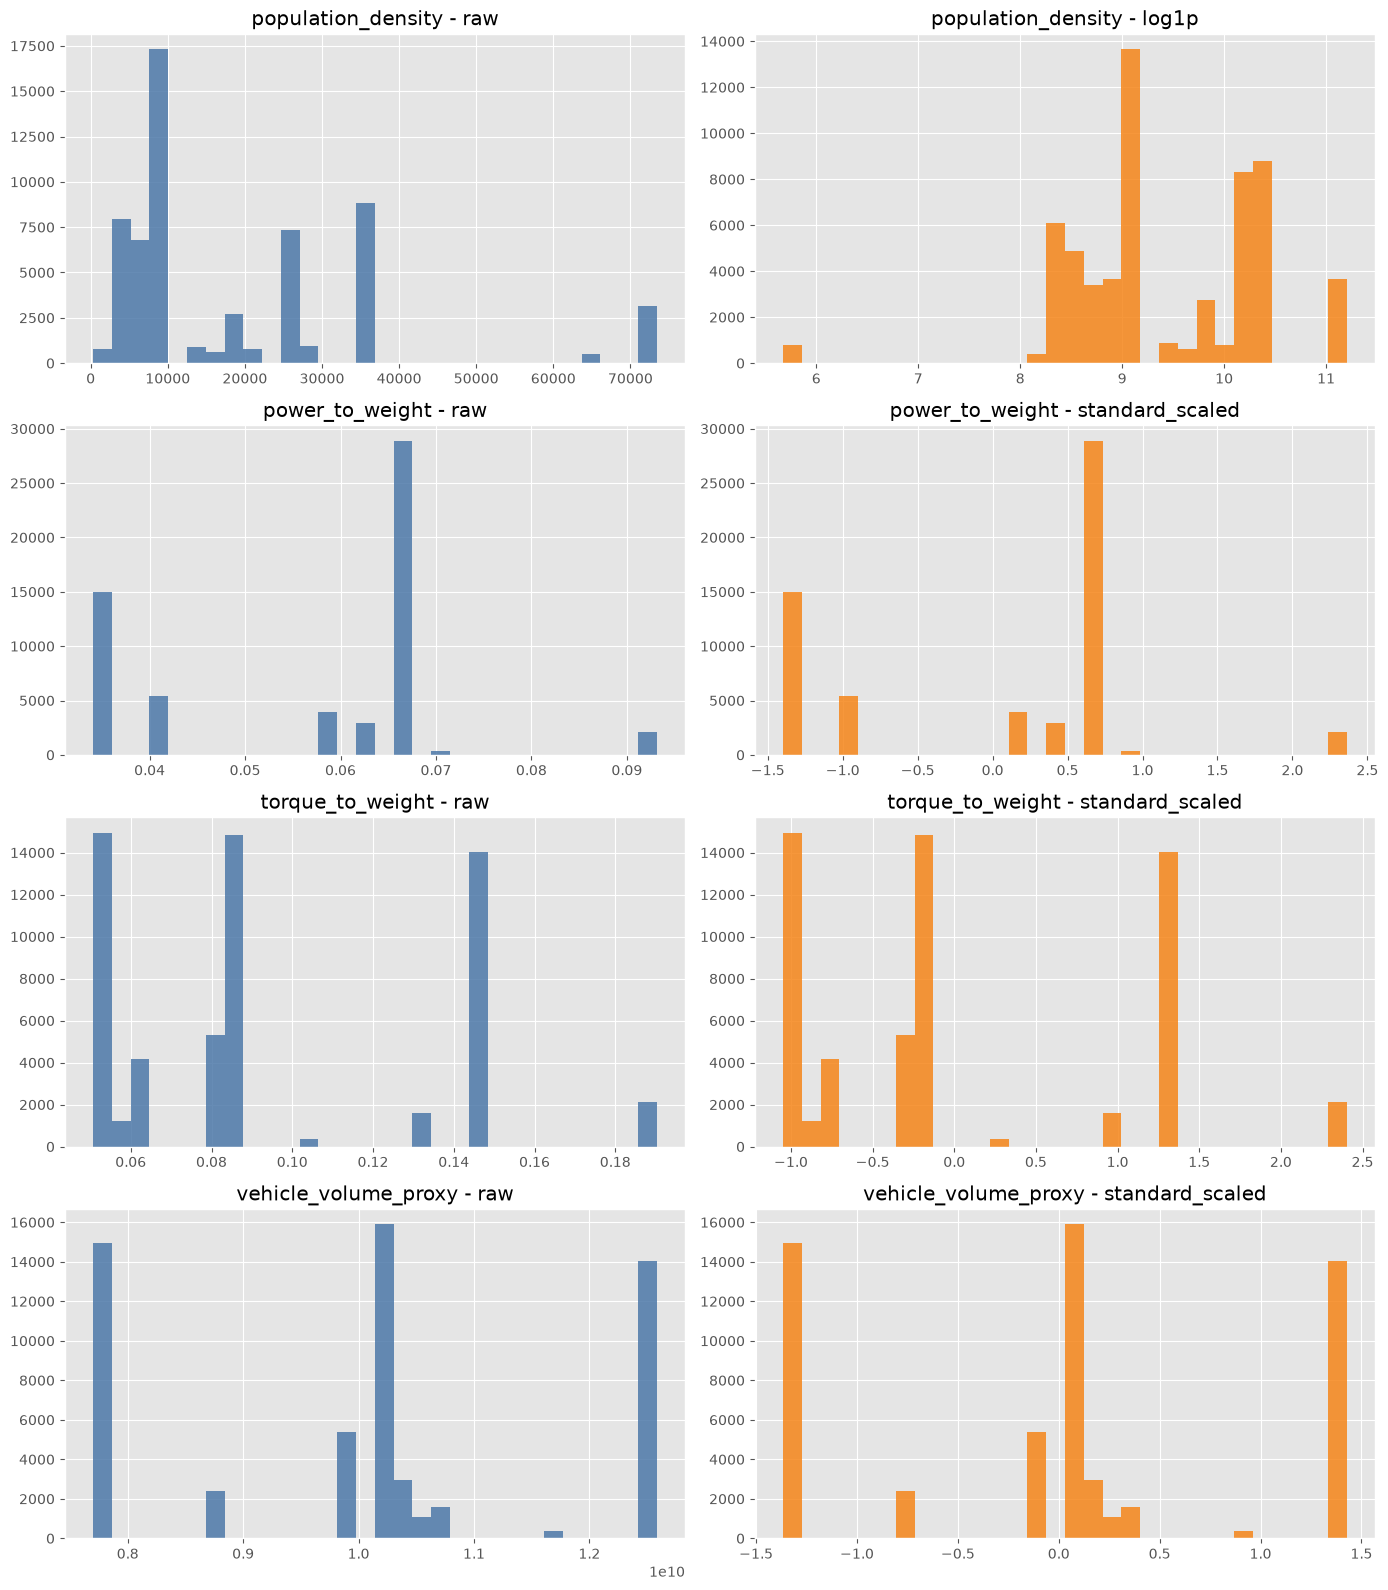

In [5]:
transform_review = enc.compare_numeric_transform_candidates(candidate_df)
display(transform_review)

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
feature_order = ['population_density', 'power_to_weight', 'torque_to_weight', 'vehicle_volume_proxy']
for row_index, feature in enumerate(feature_order):
    raw_series = candidate_df[feature].astype(float)
    if feature == 'population_density':
        transformed_series = np.log1p(raw_series)
        transform_label = 'log1p'
    else:
        transformed_series = (raw_series - raw_series.mean()) / raw_series.std()
        transform_label = 'standard_scaled'

    axes[row_index, 0].hist(raw_series, bins=30, color='#4C78A8', alpha=0.85)
    axes[row_index, 0].set_title(f'{feature} - raw')
    axes[row_index, 1].hist(transformed_series, bins=30, color='#F58518', alpha=0.85)
    axes[row_index, 1].set_title(f'{feature} - {transform_label}')

plt.tight_layout()

## Phase 4 - Class Imbalance Strategy

In [6]:
target_counts = train_df[da.TARGET_COLUMN].value_counts().sort_index()
claim_rate = float(train_df[da.TARGET_COLUMN].mean())
imbalance_review = enc.imbalance_strategy_table()

print('Class 0 count:', int(target_counts.loc[0]))
print('Class 1 count:', int(target_counts.loc[1]))
print('Positive-class rate:', f'{claim_rate:.4%}')
display(imbalance_review)

Class 0 count: 54844
Class 1 count: 3748
Positive-class rate: 6.3968%


,strategy,recommended,pros,cons
0,Class weights,Yes,Preserves all real rows and is easy to apply f...,Model support varies by algorithm and weight t...
1,Weighted loss,Yes,Preserves all real rows and is the cleanest pr...,Does not create new minority examples; thresho...
2,Random oversampling,No,Simple to implement and preserves minority-cla...,Duplicates rows and can encourage overfitting ...
3,Random undersampling,No,Fast and can rebalance classes aggressively.,Throws away a large amount of genuine majority...
4,SMOTE,No,Can enrich the minority class without exact du...,Harder to justify for mixed encoded tabular da...


## Phase 5 - Dataset Split Strategy

In [7]:
train_split, validation_split, holdout_split = enc.stratified_train_validation_holdout_split(train_df)
overlap_train_validation = len(set(train_split['policy_id']) & set(validation_split['policy_id']))
overlap_train_holdout = len(set(train_split['policy_id']) & set(holdout_split['policy_id']))
overlap_validation_holdout = len(set(validation_split['policy_id']) & set(holdout_split['policy_id']))

print('Split configuration:', enc.SPRINT3_SPLIT_CONFIG)
print('Train/validation overlap:', overlap_train_validation)
print('Train/holdout overlap:', overlap_train_holdout)
print('Validation/holdout overlap:', overlap_validation_holdout)
display(datasets['split_summary'])

Split configuration: {'train_fraction': 0.7, 'validation_fraction': 0.15, 'holdout_fraction': 0.15, 'random_seed': 42}
Train/validation overlap: 0
Train/holdout overlap: 0
Validation/holdout overlap: 0


,split,rows,class_0,class_1,claim_rate
0,train,41015,38391,2624,0.063977
1,validation,8789,8227,562,0.063944
2,holdout,8788,8226,562,0.063951


## Phase 6 - Preprocessing Pipeline

In [8]:
pipeline_summary = pd.DataFrame(
    [
        {'component': 'Dropped raw features', 'count': len(pipeline['drop_features'])},
        {'component': 'Scaled numerical + frequency features', 'count': len(pipeline['scaled_columns'])},
        {'component': 'Retained binary features', 'count': len(pipeline['binary_columns'])},
        {'component': 'Final model-ready features', 'count': len(pipeline['final_feature_names'])},
    ]
)
display(pipeline_summary)
display(datasets['X_train'].head())

,component,count
0,Dropped raw features,6
1,Scaled numerical + frequency features,26
2,Retained binary features,14
3,Final model-ready features,61


,policy_tenure,age_of_car,age_of_policyholder,population_density,airbags,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,ncap_rating,torque_nm,torque_rpm,power_bhp,power_rpm,power_to_weight,torque_to_weight,vehicle_volume_proxy,safety_feature_count,parking_assist_score,area_cluster__freq,model__freq,engine_type__freq,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,is_front_fog_lights,is_rear_window_wiper,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_speed_alert,make__1,make__2,make__3,make__4,make__5,segment__A,segment__B1,segment__B2,segment__C1,segment__C2,segment__Utility,fuel_type__CNG,fuel_type__Diesel,fuel_type__Petrol,rear_brakes_type__Disc,rear_brakes_type__Drum,transmission_type__Automatic,transmission_type__Manual,steering_type__Electric,steering_type__Manual,steering_type__Power
0,1.494089,0.539255,-1.313014,-0.750686,-0.619516,0.128560,0.769896,-0.570859,-0.233170,-0.019032,0.558353,-0.295752,-0.238097,0.170346,-0.294323,1.192347,0.342024,0.756145,0.652599,-0.208890,0.065971,0.012079,-0.733112,-0.980997,0.526127,0.526127,0,1,0,1,0,1,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,1,0,0
1,1.014034,0.539255,-0.376218,-0.878841,-0.619516,-0.615901,-1.298846,-0.570859,0.644032,-0.385379,-0.834712,-0.797957,-1.085711,0.170346,-0.595183,0.985802,-0.432721,0.210598,0.127867,-0.353817,-0.752007,-0.679359,-0.733112,-0.685875,-1.674645,-1.674645,0,0,0,0,1,0,0,0,0,1,1,0,1,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,1,0,0
2,0.601453,-0.870921,0.716710,-0.368518,-0.619516,-1.379162,-1.298846,-0.570859,-1.110372,-1.304461,-1.406225,-0.986284,-0.944442,-1.272149,-1.019123,-0.046921,-1.397539,0.756145,-1.402147,-1.050575,-1.370123,-1.025079,-0.733112,1.593573,0.716821,0.716821,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,1
3,0.719305,0.362983,0.014113,-1.176234,1.564271,0.128560,0.769896,-0.570859,-0.013870,0.446936,0.647652,-0.672405,0.115076,-1.272149,-0.294323,1.192347,0.342024,0.756145,0.427817,-0.320310,0.201700,1.394956,1.364014,-0.097228,-1.576699,-1.576699,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,1,0,1,0,0
4,0.050044,-1.047193,0.872843,0.810035,-0.619516,-1.379162,-1.298846,-0.570859,-1.110372,-1.304461,-1.406225,-0.986284,-0.944442,-1.272149,-1.019123,-0.046921,-1.397539,0.756145,-1.402147,-1.050575,-1.370123,-1.025079,-0.733112,0.190861,0.716821,0.716821,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,1


In [9]:
exported = enc.export_model_ready_datasets(datasets)
exported_paths = pd.DataFrame(
    [{'artifact': key, 'path': value} for key, value in exported.items()]
)
display(exported_paths)

,artifact,path
0,X_train,C:\Users\97252\Desktop\ML CARS project\scaffol...
1,y_train,C:\Users\97252\Desktop\ML CARS project\scaffol...
2,X_validation,C:\Users\97252\Desktop\ML CARS project\scaffol...
3,y_validation,C:\Users\97252\Desktop\ML CARS project\scaffol...
4,X_holdout,C:\Users\97252\Desktop\ML CARS project\scaffol...
5,y_holdout,C:\Users\97252\Desktop\ML CARS project\scaffol...
6,X_official_test,C:\Users\97252\Desktop\ML CARS project\scaffol...
7,split_summary,C:\Users\97252\Desktop\ML CARS project\scaffol...
8,pipeline_metadata,C:\Users\97252\Desktop\ML CARS project\scaffol...


## Phase 7 - Final Recommendation

Recommended Sprint 4 modeling input:

- dataset version: `data/processed/sprint_03_preprocessed_v1/`
- final feature width: `61`
- target handling: keep original `is_claim` labels in split-specific target files
- imbalance handling recommendation: weighted loss in the production PyTorch model, with class weights retained as the baseline-friendly equivalent for classical models
- leakage control: fit frequency maps, one-hot levels, log transform choice, and scaler parameters on the training split only

This completes Sprint 3 preprocessing and stops before any model training or benchmark evaluation.